# Freight Rate Assessment EDA

This notebook explores the supplied data before cleaning, feature engineering, and modeling. It does not modify the CSV files.

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train-test.csv')
validation = pd.read_csv(DATA_DIR / 'validation.csv')
december = pd.read_csv(DATA_DIR / 'december-chart-inputs.csv')

print(f'train-test: {train.shape}')
print(f'validation: {validation.shape}')
print(f'december inputs: {december.shape}')

train-test: (48000, 14)
validation: (12000, 13)
december inputs: (31, 7)


## 1. Schema and data quality

In [23]:
display(train.head())
display(train.dtypes.to_frame('dtype'))
display(train.isna().sum().sort_values(ascending=False).to_frame('missing_count'))

for column in ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']:
    values = pd.to_numeric(train[column], errors='coerce')
    print(f'{column}: invalid={values.isna().sum()}, negative={(values < 0).sum()}')

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


,dtype
load_id,object
pickup,object
delivery,object
pickup_lat,float64
pickup_lon,float64
delivery_lat,float64
delivery_lon,float64
distance,float64
equipment,object
weight,float64


,missing_count
market_index,374
weight,300
delivery,0
pickup_lat,0
load_id,0
pickup,0
delivery_lat,0
pickup_lon,0
distance,0
delivery_lon,0


distance: invalid=0, negative=0
weight: invalid=300, negative=292
market_index: invalid=374, negative=0
quote_signal: invalid=0, negative=0
posted_rate: invalid=0, negative=0


## 2. Validation data quality

In [24]:
display(validation.head())
display(validation.dtypes.to_frame('dtype'))
display(validation.isna().sum().sort_values(ascending=False).to_frame('missing_count'))

for column in ['distance', 'weight', 'market_index', 'quote_signal']:
    values = pd.to_numeric(validation[column], errors='coerce')
    print(f'{column}: invalid={values.isna().sum()}, negative={(values < 0).sum()}')

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


,dtype
load_id,object
pickup,object
delivery,object
pickup_lat,float64
pickup_lon,float64
delivery_lat,float64
delivery_lon,float64
distance,float64
equipment,object
weight,float64


,missing_count
market_index,249
weight,165
delivery,0
pickup,0
load_id,0
pickup_lon,0
pickup_lat,0
delivery_lat,0
delivery_lon,0
equipment,0


distance: invalid=0, negative=0
weight: invalid=165, negative=145
market_index: invalid=249, negative=0
quote_signal: invalid=0, negative=0


## 3. Target and date coverage

Training date range: 2025-01-01 00:00:00 to 2025-10-31 00:00:00
Validation date range: 2025-11-01 00:00:00 to 2025-12-31 00:00:00


,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


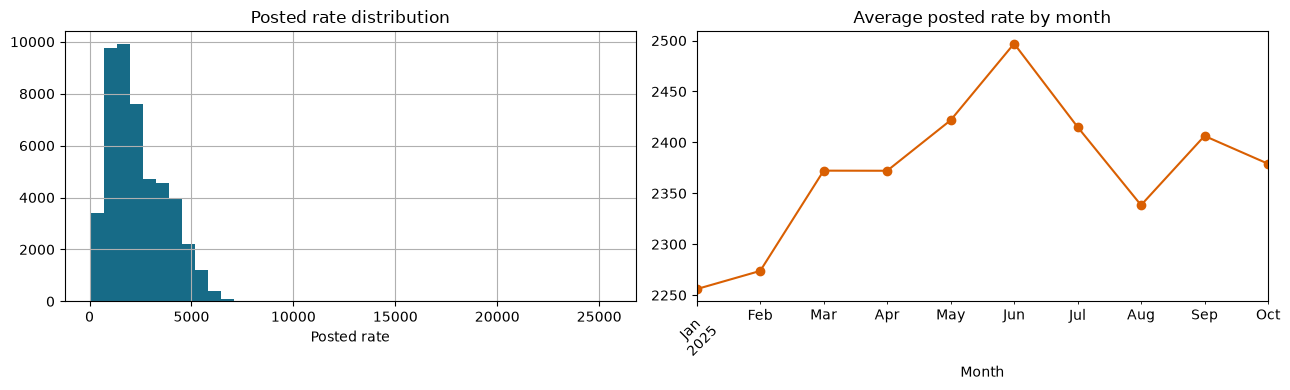

In [15]:
train['date'] = pd.to_datetime(train['date'], errors='coerce')
validation['date'] = pd.to_datetime(validation['date'], errors='coerce')
print('Training date range:', train['date'].min(), 'to', train['date'].max())
print('Validation date range:', validation['date'].min(), 'to', validation['date'].max())
display(train['posted_rate'].describe().to_frame('posted_rate'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train['posted_rate'].hist(ax=axes[0], bins=40, color='#176b87')
axes[0].set_title('Posted rate distribution')
axes[0].set_xlabel('Posted rate')
train.groupby(train['date'].dt.to_period('M'))['posted_rate'].mean().plot(ax=axes[1], marker='o', color='#d95f02')
axes[1].set_title('Average posted rate by month')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

## 4. Categorical features

In [16]:
for column in ['equipment', 'pickup', 'delivery']:
    print(f'{column}: {train[column].nunique(dropna=False)} unique values')
    display(train[column].value_counts(dropna=False).head(15).to_frame('count'))

display(train.groupby('equipment', dropna=False)['posted_rate'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False))

equipment: 3 unique values


,count
equipment,
Dry Van,27202
Reefer,12045
Flatbed,8753


pickup: 64 unique values


,count
pickup,
Oklahoma City,1242
Lexington,1209
Bakersfield,1193
Fort Wayne,1170
Hartford,1150
Richmond,1140
Nashville,1124
Phoenix,1121
Baton Rouge,1115


delivery: 64 unique values


,count
delivery,
Lexington,1197
Fort Wayne,1176
Baton Rouge,1167
Bakersfield,1156
Hartford,1143
Oklahoma City,1140
Richmond,1109
Atlanta,1096
Phoenix,1090


,count,mean,median
equipment,,,
Reefer,12045,2553.636939,2196.670
Flatbed,8753,2445.087223,2076.810
Dry Van,27202,2271.548686,1953.035


## 5. Numeric relationships with the target

,count,mean,std,min,25%,50%,75%,max
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


,correlation_with_posted_rate
posted_rate,1.000000
distance,0.908519
weight,0.034840
market_index,0.034165
quote_signal,-0.039858


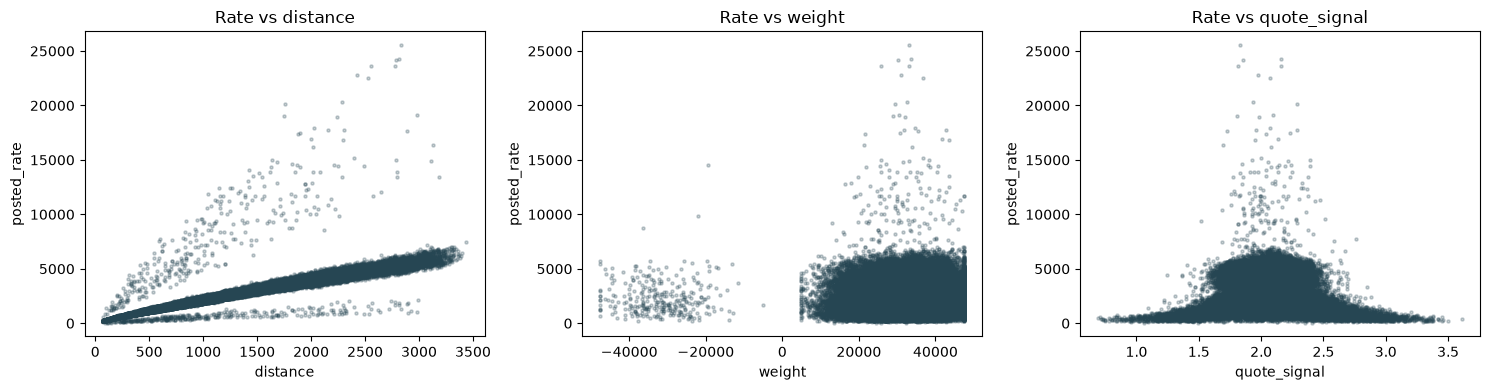

In [17]:
numeric_columns = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
display(train[numeric_columns].describe().transpose())
display(train[numeric_columns].corr()['posted_rate'].sort_values(ascending=False).to_frame('correlation_with_posted_rate'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ['distance', 'weight', 'quote_signal']):
    axes[list(['distance', 'weight', 'quote_signal']).index(column)].scatter(train[column], train['posted_rate'], s=5, alpha=0.25, color='#264653')
    axis.set_title(f'Rate vs {column}')
    axis.set_xlabel(column)
    axis.set_ylabel('posted_rate')
plt.tight_layout()

## Initial decision checklist

After running the cells, record observations here: which columns need imputation, whether negative weights/distances exist, whether rates trend over time, and which features appear useful. Use a chronological split for validation because the task asks for future validation predictions.

### Cleaning decision

`weight` needs the most attention: the training data contains 300 missing values and 292 negative values. Negative weights are physically impossible, so `clean_data()` converts distance and weight to absolute values before median imputation. Missing `market_index` values are also replaced with the median. The same cleaning function is used for training, validation, and December inputs.

### Invalid numeric values

The EDA checks all numeric columns for invalid and negative values rather than assuming the training file is the only affected input. The cleaning step replaces infinite values with missing values, then fills numeric gaps using the median of the current dataframe. Source CSVs remain unchanged during this step.

### Time pattern

Monthly average posted rates should be read from the chart above rather than treated as a random fluctuation. The date parts in the model allow weekday and monthly patterns to be learned. December predictions can therefore vary by day while keeping the route, equipment, distance, and weight fixed.

### Useful predictors

Distance is the strongest individual signal, with approximately 0.91 correlation with `posted_rate`. Weight, market index, and quote signal have weak standalone linear correlations, so correlation alone is not enough to discard them. However, the December input does not contain coordinates, `market_index`, or `quote_signal`, so the final shared model uses distance, weight, equipment, lane, date parts, distance transforms, and weight per mile.

### Model target

The target is heavily right-skewed, ranging from roughly $57 to $25,533. Both candidate models train on `log1p(posted_rate)` and convert predictions back to dollar units with `expm1`, reducing the influence of unusually large loads during fitting.

### Validation decision

The split is chronological: train on January through August 2025 and hold out September through October 2025. This mirrors the real task, where November and later loads are future observations. A random split was avoided because it could mix future-like rows into training and produce an overly optimistic estimate.